In [1]:
from coniferest.isoforest import IsolationForest
from coniferest.aadforest import AADForest
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../..')

from rb_clf_V2.scripts.utils import plot_config
from rb_clf_V2.scripts.train_RBclf import load_single, get_akb_labels

plot_config()

In [2]:
oids, features = load_single('../../dr23-features/sid_snad_clf_r_100.dat', '../../dr23-features/extended_features.dat')

In [3]:
def get_z_vectors(train_features, val_features, n_estimators=100, rs=666):
    t = time.monotonic()
    iforest = IsolationForest(random_seed=rs, n_jobs=20, n_trees=n_estimators).fit(train_features)
    t = (time.monotonic() - t) / 60
    print(f'Forest fitted in {t:.0f} m')
    
    x_leafs = iforest.apply(val_features)
    z_vectors = np.zeros((x_leafs.shape[0], x_leafs.max() + 1))
    for i in range(len(z_vectors)):
        z_vectors[i][x_leafs[i]] = np.ones(len(z_vectors[i][x_leafs[i]]))
        
    return z_vectors, iforest

def calc_acc(z_vectors, val_labels):
    acc = np.zeros(z_vectors.shape[1])
    for i in range(z_vectors.shape[1]):
        acc[i] = np.sum(z_vectors[:, i] == val_labels) / z_vectors.shape[0]
    
    return acc

In [4]:
akb = get_akb_labels(f'../data/akb.ztf.snad.space.json')

crossmatch = np.load(f'../data/crossmatch.npy')
akb_features = features[crossmatch] 
akb_labels = 1 - np.array([akb[oid] for oid in oids[crossmatch]])

In [16]:
(akb_labels == 1).sum() / len(akb_labels)

np.float64(0.5560654734587731)

In [9]:
n_trees = 100
rs = 100
z_vec_dr23, _ = get_z_vectors(features[:, :-1], akb_features[:, :-1], n_estimators=n_trees, rs=rs)

Forest fitted in 0 m


In [10]:
acc_dr23 = calc_acc(z_vec_dr23, akb_labels)
print(f'DR23 accuracy\nmean = {np.mean(acc_dr23):.3f}     std = {np.std(acc_dr23):.3f}')

DR23 accuracy
mean = 0.446     std = 0.020


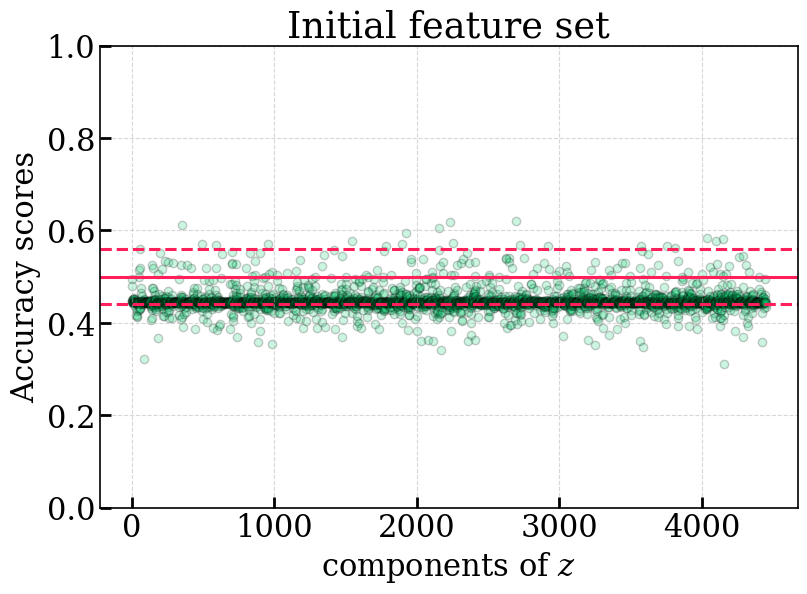

In [11]:
fig, ax = plt.subplots(figsize=(9,6))
plt.scatter(np.arange(len(acc_dr23)), acc_dr23, color=u'#00CD6C', alpha=0.2, edgecolors='black')#u'#00CD6C'  u'#009ADE'  u'#FFC61E'  u'#AF58BA'
plt.axhline(y=0.5, color=u'#FF1F5B', linestyle='-', label=r'$\mu$')
plt.axhline(y=0.5+3*np.std(acc_dr23), color=u'#FF1F5B', linestyle='--', alpha=1)
plt.axhline(y=0.5-3*np.std(acc_dr23), color=u'#FF1F5B', linestyle='--', alpha=1, label=r'$\pm3\sigma$')
plt.xlabel('components of $z$')
plt.ylabel('Accuracy scores')
plt.title('Initial feature set')
plt.ylim(0,1)
ax.grid('on')
#ax.text(500, 0.9, f'number of trees: {n_trees}')
#plt.legend(ncol=2, borderpad=0.3)
#plt.savefig('plots/snad4/onehot_acc_snad4_bigfont.pdf', dpi=400, format='pdf', bbox_inches="tight")

# Augmented features

In [12]:
n_trees = 100
rs = 100
z_vec_dr23_art, _ = get_z_vectors(features, akb_features, n_estimators=n_trees, rs=rs)

Forest fitted in 0 m


In [13]:
acc_dr23_art = calc_acc(z_vec_dr23_art, akb_labels)
print(f'DR23 accuracy\nmean = {np.mean(acc_dr23_art):.3f}     std = {np.std(acc_dr23_art):.3f}')

DR23 accuracy
mean = 0.446     std = 0.024


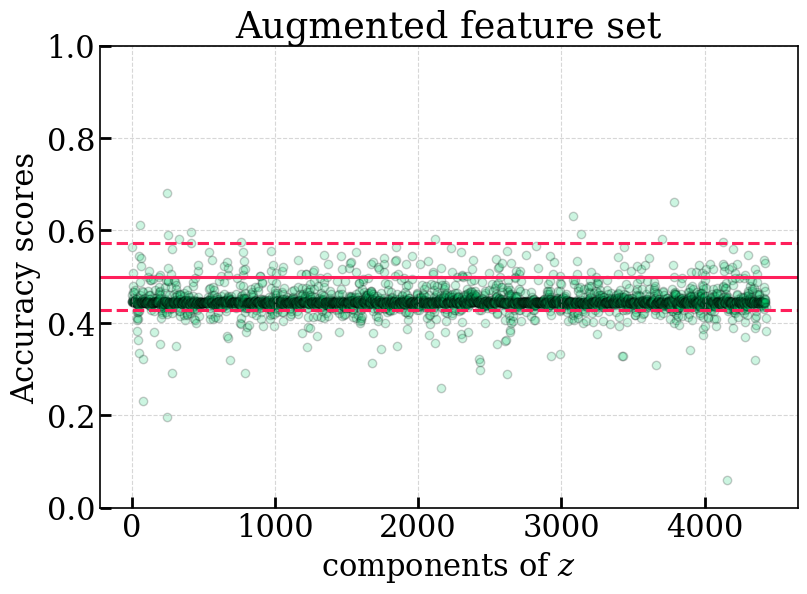

In [14]:
fig, ax = plt.subplots(figsize=(9,6))
plt.scatter(np.arange(len(acc_dr23_art)), acc_dr23_art, color=u'#00CD6C', alpha=0.2, edgecolors='black')#u'#00CD6C'  u'#009ADE'  u'#FFC61E'  u'#AF58BA'
plt.axhline(y=0.5, color=u'#FF1F5B', linestyle='-', label=r'$\mu$')
plt.axhline(y=0.5+3*np.std(acc_dr23_art), color=u'#FF1F5B', linestyle='--', alpha=1)
plt.axhline(y=0.5-3*np.std(acc_dr23_art), color=u'#FF1F5B', linestyle='--', alpha=1, label=r'$\pm3\sigma$')
plt.xlabel('components of $z$')
plt.ylabel('Accuracy scores')
plt.title('Augmented feature set')
plt.ylim(0,1)
ax.grid('on')
#ax.text(500, 0.9, f'number of trees: {n_trees}')
#plt.legend(ncol=2, borderpad=0.3)
#plt.savefig('plots/snad4/onehot_acc_snad4_bigfont.pdf', dpi=400, format='pdf', bbox_inches="tight")

In [ ]:
a